# DAiSEE Comprehensive Academic State Analysis
### Intensity vs. Presence (AUs)
In this notebook, we analyze both the **Intensity (_r)** and the **Presence (_c)** of Action Units.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", palette="viridis")
labels = ['Boredom', 'Engagement', 'Confusion', 'Frustration']
df = pd.read_csv('Data/Cleaned/3_Changepoint/3_Changepoint_Train.csv')

## 1. Class Distribution
Printing counts and percentages for every academic state.


BOREDOM:
  Level 0: 7422 (45.5%)
  Level 1: 5253 (32.2%)
  Level 2: 3183 (19.5%)
  Level 3: 453 (2.8%)

ENGAGEMENT:
  Level 0: 102 (0.6%)
  Level 1: 621 (3.8%)
  Level 2: 7875 (48.3%)
  Level 3: 7713 (47.3%)

CONFUSION:
  Level 0: 10986 (67.4%)
  Level 1: 3828 (23.5%)
  Level 2: 1299 (8.0%)
  Level 3: 198 (1.2%)

FRUSTRATION:
  Level 0: 12756 (78.2%)
  Level 1: 2850 (17.5%)
  Level 2: 576 (3.5%)
  Level 3: 129 (0.8%)


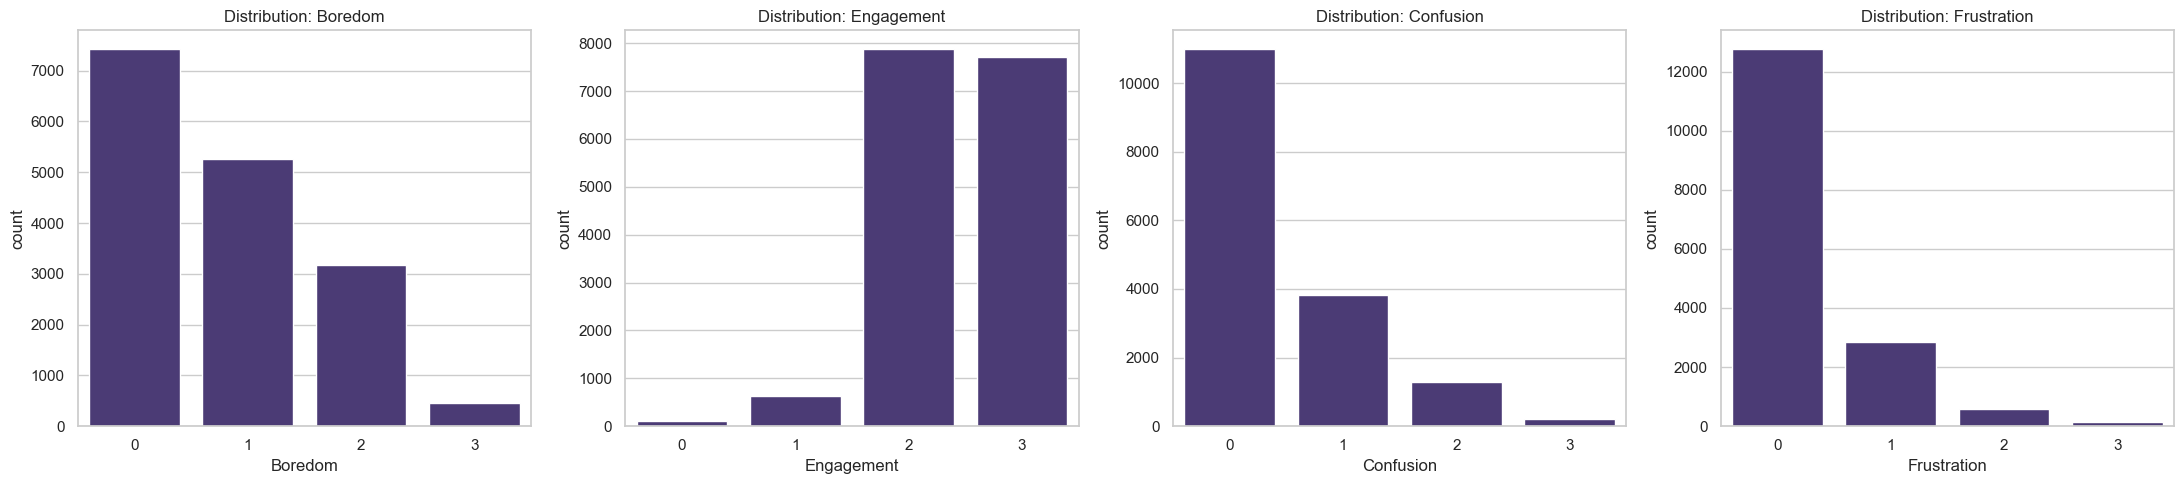

In [2]:
for label in labels:
    counts = df[label].value_counts().sort_index()
    percentages = df[label].value_counts(normalize=True).sort_index() * 100
    print(f"\n{label.upper()}:")
    for val, count in counts.items():
        print(f"  Level {int(val)}: {count} ({percentages[val]:.1f}%)")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, label in enumerate(labels):
    sns.countplot(x=label, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution: {label}')
plt.tight_layout()
plt.show()

## 2. AU Intensity Analysis (_r)
This heatmap shows the **average strength** (0-5) of facial muscle movements.

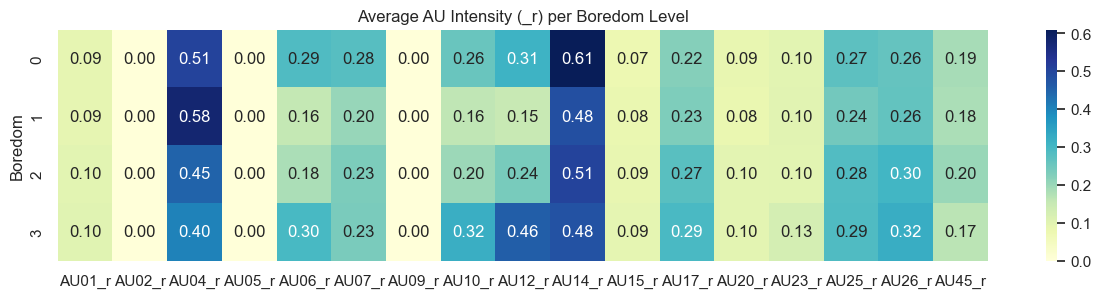

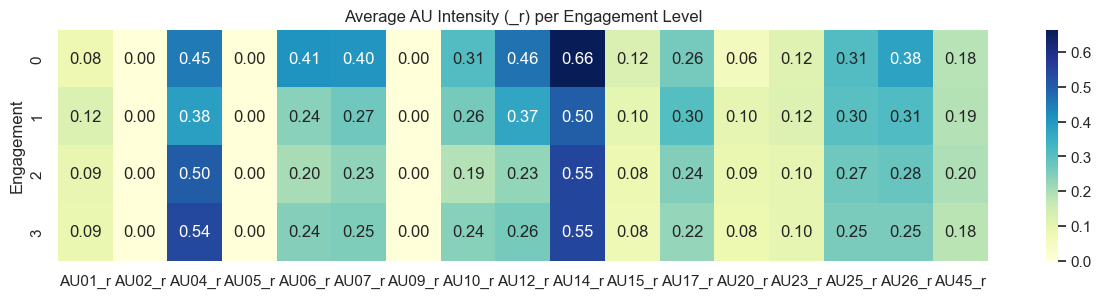

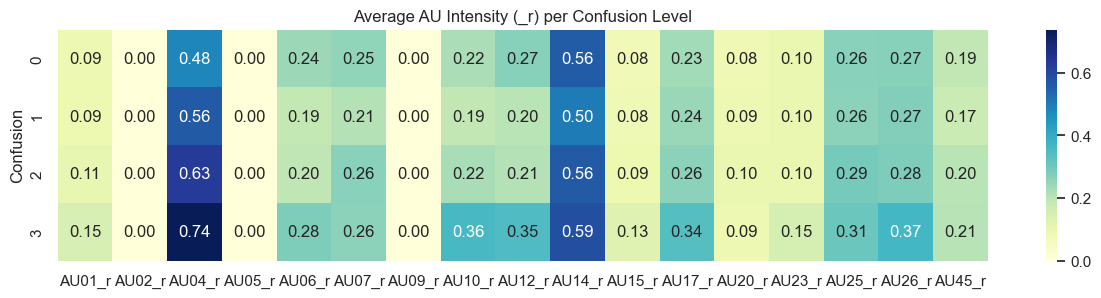

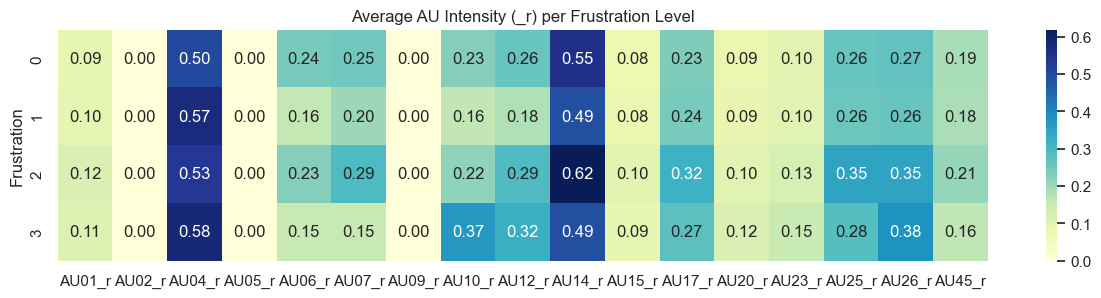

In [3]:
au_r_cols = [c for c in df.columns if c.startswith('AU') and c.endswith('_r')]
for label in labels:
    plt.figure(figsize=(15, 3))
    sns.heatmap(df.groupby(label)[au_r_cols].mean(), annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title(f"Average AU Intensity (_r) per {label} Level")
    plt.show()

## 3. AU Presence Analysis (_c)
This heatmap shows the **Frequency** (0% to 100%) that a muscle was active. 

*Interpretation: A value of 0.45 means the muscle was active in 45% of the frames for that group.*

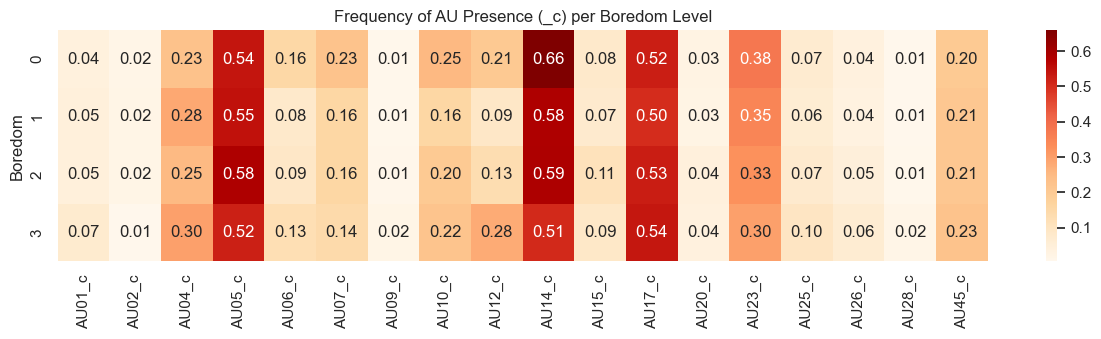

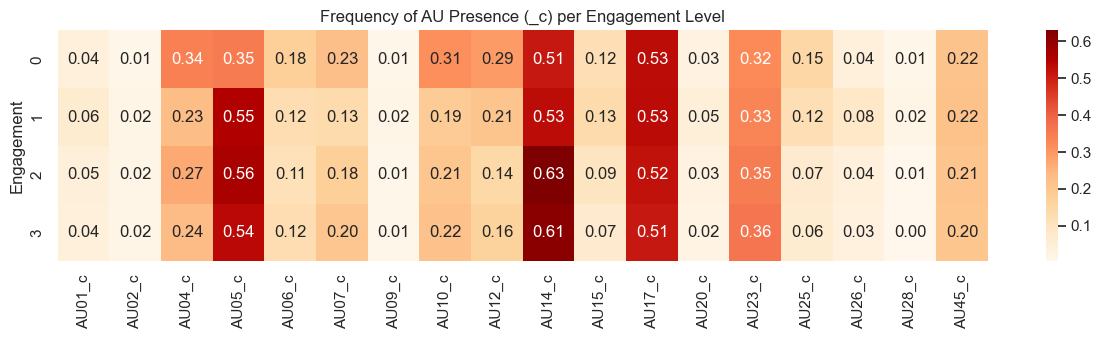

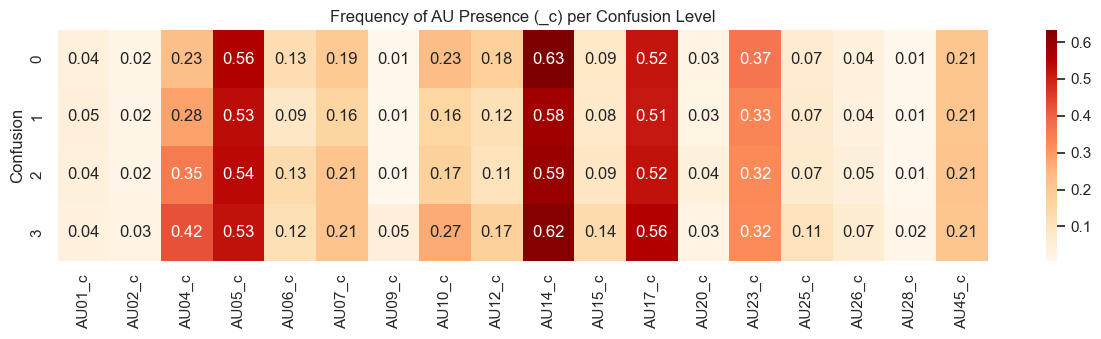

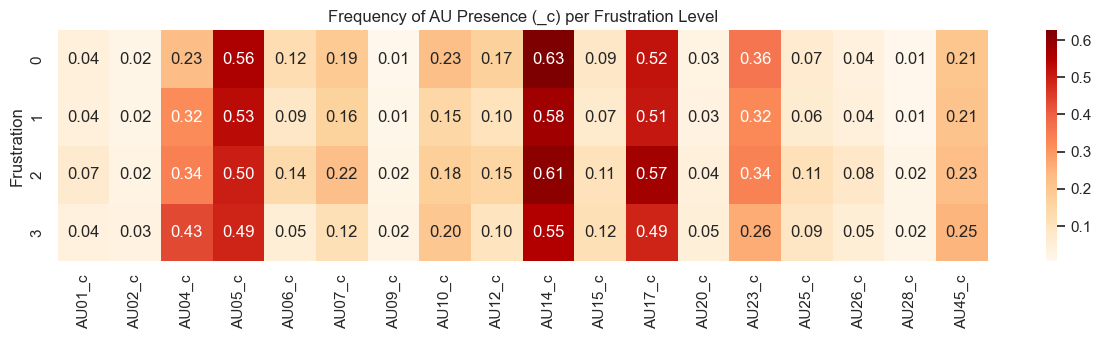

In [4]:
au_c_cols = [c for c in df.columns if c.startswith('AU') and c.endswith('_c')]
for label in labels:
    plt.figure(figsize=(15, 3))
    # Taking the mean of binary values (0,1) gives the probability/frequency
    sns.heatmap(df.groupby(label)[au_c_cols].mean(), annot=True, cmap="OrRd", fmt=".2f")
    plt.title(f"Frequency of AU Presence (_c) per {label} Level")
    plt.show()

## 4. Gaze Analysis
Does students' focus deviate more as they become more frustrated or bored?

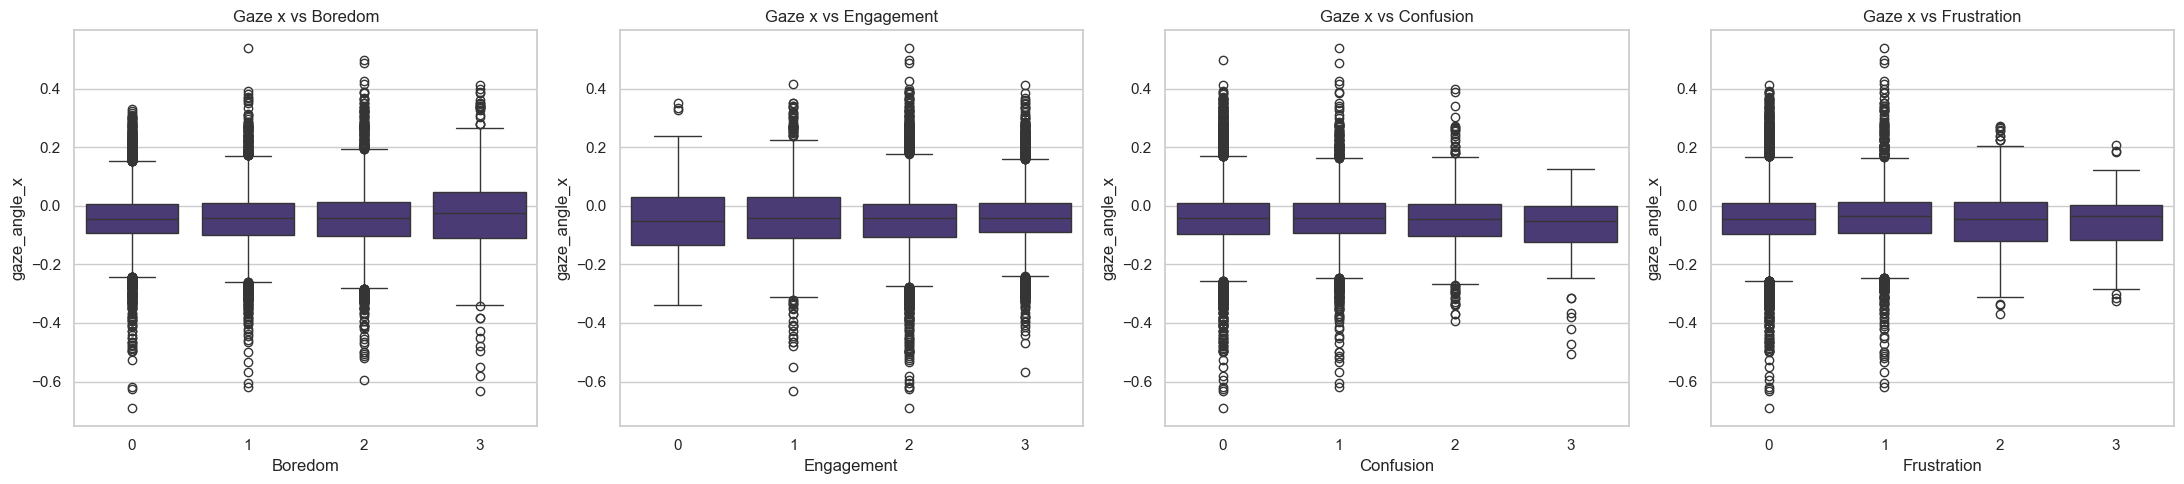

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, label in enumerate(labels):
    sns.boxplot(x=label, y='gaze_angle_x', data=df, ax=axes[i])
    axes[i].set_title(f"Gaze x vs {label}")
plt.tight_layout()
plt.show()